In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 72

In [2]:
catalog = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
# catalog = "/global/homes/f/feng045/program/hackathon/catalog/NERSC/main.yaml"

current_location = "online"
# current_location = "NERSC"
source = "casesm2_10km_nocumulus"
# source = "icon_d3hp003"
#source = "um_glm_n2560_RAL3p3"
#source = "ifs_tco3999-ng5_rcbmf_cf"
#source = "scream-dkrz"

# zoom = 9
# time = "PT1H"

zoom = 8
# time = "PT1H"
# time = "PT3H"
time = "PT6H"

lats, latN = -20, 20

cat = intake.open_catalog(catalog)[current_location]

# cat = intake.open_catalog(catalog)
ds = cat[source](zoom=zoom, time=time).to_dask()
ds = ds.pipe(egh.attach_coords)
ds 

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 919GB
Dimensions:  (time: 1460, lev: 25, cell: 786432)
Coordinates:
  * lev      (lev) int64 200B 1000 975 950 925 900 875 850 ... 70 50 30 20 10 5
  * time     (time) datetime64[ns] 12kB 2020-03-01T06:00:00 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    hur      (time, lev, cell) float32 115GB ...
    hus      (time, lev, cell) float32 115GB ...
    orog     (cell) float32 3MB ...
    qall     (time, lev, cell) float32 115GB ...
    sftgif   (cell) float32 3MB ...
    sftlf    (cell) float32 3MB ...
    ta       (time, lev, cell) float32 115GB ...
    ua       (time, lev, cell) float32 115GB ...
    va       (time, lev, cell) float32 115GB ...
    wa       (time, lev, cell) float32 115GB ...
    zg       (time, lev, cell) float32 115GB ...
Attributes:
    NCO:                        netCDF Operators version 5.3.2 (Homepage = ht...
    history:                    Fri Feb 21 12:18:22 2025: ncks -m -A -C -v PH...
    history_of_appended_files:  Fri Feb 21 12:18:22 2025: Appended file IAP_t...
    source:                     IAP

In [3]:
ds.lev.values

array([1000,  975,  950,  925,  900,  875,  850,  825,  800,  750,  700,
        600,  500,  400,  300,  250,  200,  150,  100,   70,   50,   30,
         20,   10,    5])

In [4]:
ds.wa.attrs

{}

In [12]:
ds.zg.attrs

{}

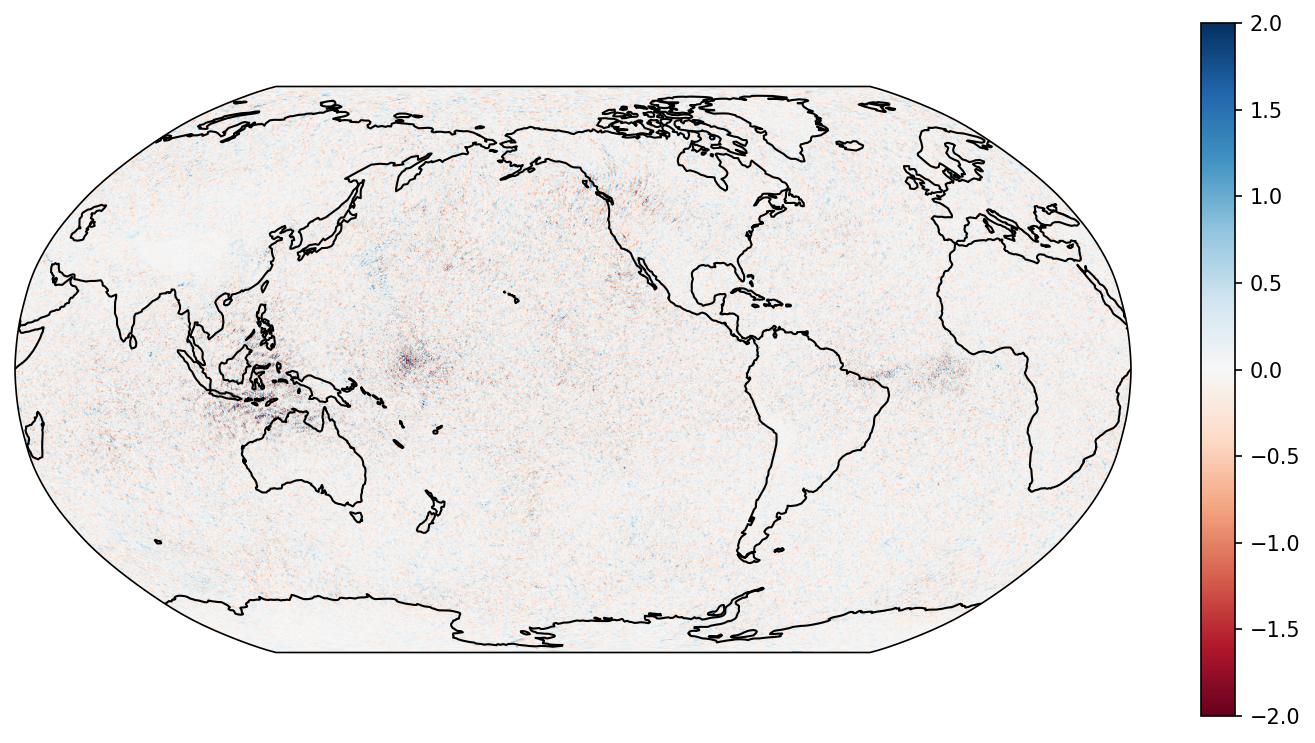

In [29]:
# fig = plt.figure(figsize=(15, 8), dpi=150)
fig, ax = plt.subplots(1, 1,figsize=(12, 6), dpi=150,
                       subplot_kw={'projection': ccrs.Robinson(central_longitude=-137)})
ax.set_global()
im = egh.healpix_show(ds.wa.isel(time=200).sel(lev=500), vmin=-2, vmax=2, cmap='RdBu', ax=ax)
ax.coastlines()
plt.colorbar(im, orientation='vertical', ax=ax)

In [6]:
cat[source](zoom=zoom, time=time).urlpath

'https://s3.eu-dkrz-1.dkrz.cloud/wrcp-hackathon/data/CAS-ESM2/CAS-ESM2_10km_nocumulus_PT6H_z8.zarr'

In [7]:
# Read 2D data at 3-hourly intervals
ds2d = cat[source](zoom=zoom, time="PT3H").to_dask()
ds2d = ds2d.pipe(egh.attach_coords)
ds2d

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 322GB
Dimensions:  (time: 2920, cell: 786432)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2020-03-01T03:00:00 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables: (12/38)
    clt      (time, cell) float32 9GB ...
    hflsd    (time, cell) float32 9GB ...
    hfssd    (time, cell) float32 9GB ...
    huss     (time, cell) float32 9GB ...
    mrso     (time, cell) float32 9GB ...
    orog     (cell) float32 3MB ...
    ...       ...
    tauu     (time, cell) float32 9GB ...
    tauv     (time, cell) float32 9GB ...
    ts       (time, cell) float32 9GB ...
    u10      (time, cell) float32 9GB ...
    uas      (time, cell) float32 9GB ...
    vas      (time, cell) float32 9GB ...
Attributes:
    NCO:                        netCDF Operators version 5.3.2 (Homepage = ht...
    history:                    Fri Feb 21 12:18:22 2025: ncks -m -A -C -v PH...
    history_of_appended_files:  Fri Feb 21 12:18:22 2025: Appended file IAP_t...
    source:                     IAP

In [8]:
ds2d.pr.attrs

{}

In [9]:
ds2d.prw.attrs

{'cell_methods': 'time: mean',
 'long_name': 'Total (vertically integrated) precipitatable water',
 'units': 'kg/m2'}

In [10]:
# zarr_file = '/pscratch/sd/w/wcmca1/hackathon/NICAM/NICAM_2d1h_z9.zarr'

# Read zomm 8 data
ds8 = cat[source](zoom=8, time=time).to_dask()
ds8 = ds8.pipe(egh.attach_coords)
ds8

ds7 = cat[source](zoom=7, time=time).to_dask()
ds7 = ds7.pipe(egh.attach_coords)

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [11]:
ds8.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2020-03-01T06:00:00.000000000', '2020-03-01T12:00:00.000000000',
       '2020-03-01T18:00:00.000000000', '2020-03-02T00:00:00.000000000',
       '2020-03-02T06:00:00.000000000', '2020-03-02T12:00:00.000000000',
       '2020-03-02T18:00:00.000000000', '2020-03-03T00:00:00.000000000',
       '2020-03-03T06:00:00.000000000', '2020-03-03T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 2020-03-01T06:00:00 ... 2020-03-03T12:...
    crs      int64 8B 0
Attributes:
    bounds:     time_bnds
    long_name:  time